In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for cand in [here, *here.parents]:
    if (cand / "correlation_trends" / "__init__.py").exists():
        root = cand; break
else:
    raise FileNotFoundError(f"correlation_trends not found above {here}")
if str(root) not in sys.path:
    sys.path.insert(0, str(root))
print("repo root on path:", root)

import numpy as np
import matplotlib.pyplot as plt
from amocatlas import read

transports = read.rapid()      # the 26N transports (MOC, TRANS_FC, TRANS_EKMAN, TRANS_UMO)
print(transports)              # inspect variables, units, TIME grid

repo root on path: /Users/mac/Desktop/SCHOOL/data analysis/assignment2
Loading 1 RAPID 26°N dataset(s):
  0. moc_transports.nc: RAPID layer transport time series

<xarray.Dataset> Size: 1MB
Dimensions:           (TIME: 14599)
Coordinates:
  * TIME              (TIME) datetime64[ns] 117kB 2004-04-02 ... 2024-03-27
Data variables:
    TRANS_0_800       (TIME) float64 117kB ...
    TRANS_800_1100    (TIME) float64 117kB ...
    TRANS_1100_3000   (TIME) float64 117kB ...
    TRANS_3000_5000   (TIME) float64 117kB ...
    TRANS_below_5000  (TIME) float64 117kB ...
    TRANS_FC          (TIME) float64 117kB ...
    TRANS_EKMAN       (TIME) float64 117kB ...
    TRANS_UMO         (TIME) float64 117kB ...
    MOC               (TIME) float64 117kB ...
Attributes: (12/37)
    title:                                 RAPID MOC timeseries
    summary:                               RAPID 26N transport estimates dataset
    description:                           RAPID 26N transport estimates dataset


In [2]:
# the two Part 2A series as xarray DataArrays (keep TIME for seasonal grouping)
moc = transports["MOC"]
umo = transports["TRANS_UMO"]

# basic reporting (required by the brief)
time = transports["TIME"].values
dt_days = float(np.median(np.diff(time)) / np.timedelta64(1, "D"))
print(f"N = {moc.sizes['TIME']}, dt = {dt_days:.3f} days, "
      f"span {str(time[0])[:10]} to {str(time[-1])[:10]}")
print("MOC:  ", int(np.isnan(moc).sum().item()), "NaNs")
print("UMO:  ", int(np.isnan(umo).sum().item()), "NaNs")

N = 14599, dt = 0.500 days, span 2004-04-02 to 2024-03-27
MOC:   20 NaNs
UMO:   20 NaNs


MOC mean raw vs deseasonalised: 16.976918462067626 16.976918462067626
MOC var  raw vs deseasonalised: 19.375420207883195 16.97620177660963


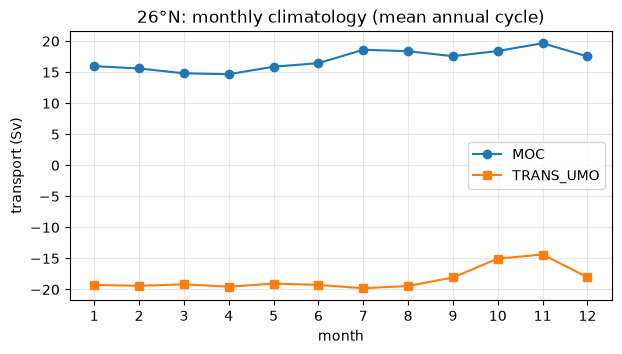

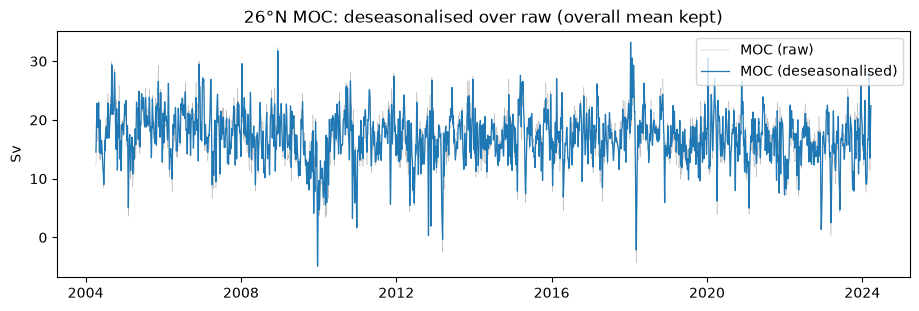

In [3]:
from correlation_trends.seasonal import seasonal_climatology, remove_seasonal_cycle

FIG_DIR = root / "figures"; FIG_DIR.mkdir(exist_ok=True)

# monthly climatology (the mean annual cycle) and deseasonalised series
clim_moc = seasonal_climatology(moc)
clim_umo = seasonal_climatology(umo)
moc_des  = remove_seasonal_cycle(moc)
umo_des  = remove_seasonal_cycle(umo)

# sanity: mean preserved, seasonal wiggle gone
print("MOC mean raw vs deseasonalised:", float(moc.mean()), float(moc_des.mean()))
print("MOC var  raw vs deseasonalised:", float(moc.var()),  float(moc_des.var()))

# --- Figure: monthly climatology (both series) ---
figS, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(clim_moc["month"], clim_moc, "o-", label="MOC")
ax.plot(clim_umo["month"], clim_umo, "s-", label="TRANS_UMO")
ax.set_xlabel("month"); ax.set_ylabel("transport (Sv)")
ax.set_title("26°N: monthly climatology (mean annual cycle)")
ax.set_xticks(range(1, 13)); ax.legend(); ax.grid(alpha=0.3)
figS.savefig(FIG_DIR / "fig2A_climatology.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Figure: deseasonalised over raw, MEAN KEPT (MOC) ---
figD, ax = plt.subplots(figsize=(11, 3.2))
ax.plot(moc["TIME"], moc,     lw=0.3, color="0.7", label="MOC (raw)")
ax.plot(moc["TIME"], moc_des, lw=0.9, color="C0",  label="MOC (deseasonalised)")
ax.set_ylabel("Sv"); ax.set_title("26°N MOC: deseasonalised over raw (overall mean kept)")
ax.legend(loc="upper right"); figD.savefig(FIG_DIR / "fig2A_moc_deseasonalised.png", dpi=150, bbox_inches="tight")
plt.show()

MOC: T* = 18.7 days, N = 14579, N_eff = 195


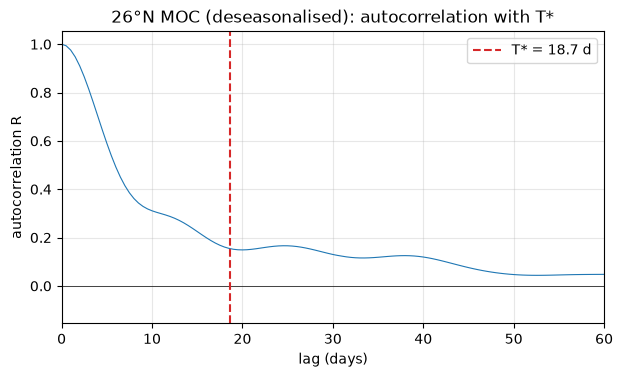

In [4]:
from correlation_trends.correlation import autocorr, integral_timescale, effective_dof

# work on the DESEASONALISED series (persistence of the anomalies, not the annual cycle)
moc_des_vals = moc_des.values
moc_des_vals = moc_des_vals[np.isfinite(moc_des_vals)]   # drop the ~20 NaNs

R      = autocorr(moc_des_vals, biased=True)
tstar  = integral_timescale(moc_des_vals, dt_days, biased=True)   # in days
n_eff  = effective_dof(moc_des_vals, dt_days)
print(f"MOC: T* = {tstar:.1f} days, N = {moc_des_vals.size}, N_eff = {n_eff:.0f}")

lags_days = np.arange(R.size) * dt_days
figR, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(lags_days, R, lw=0.8)
ax.axhline(0, color="k", lw=0.5)
ax.axvline(tstar, color="C3", ls="--", label=f"T* = {tstar:.1f} d")
ax.set_xlim(0, 60)                       # zoom to the decorrelation scale (days)
ax.set_xlabel("lag (days)"); ax.set_ylabel("autocorrelation R")
ax.set_title("26°N MOC (deseasonalised): autocorrelation with T*")
ax.legend(); ax.grid(alpha=0.3)
figR.savefig(FIG_DIR / "fig2A_moc_autocorr.png", dpi=150, bbox_inches="tight")
plt.show()

=== 26°N MOC trend (deseasonalised) ===
slope        : -0.0947 Sv/yr
SE (naive)   : 0.0059   SE (eff): 0.0473
slope/SE     : t_naive=-16.13   t_eff=-2.00
N_eff        : 224  (of N=14579)
p-value      : p_naive=4.69e-58   p_eff=0.047
verdict (95%): SIGNIFICANT


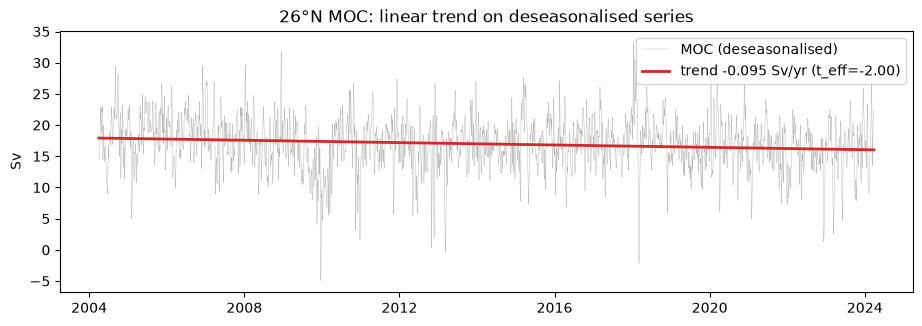

In [5]:
from correlation_trends.trends import trend_with_significance

# time in YEARS so the slope is in Sv/year (interpretable)
t_years = (moc["TIME"].values - moc["TIME"].values[0]) / np.timedelta64(365, "D")

# fit on the deseasonalised series, dropping the NaNs consistently
mask = np.isfinite(moc_des.values)
res_moc = trend_with_significance(t_years[mask], moc_des.values[mask], dt=dt_days)

print("=== 26°N MOC trend (deseasonalised) ===")
print(f"slope        : {res_moc.slope:.4f} Sv/yr")
print(f"SE (naive)   : {res_moc.se:.4f}   SE (eff): {res_moc.se_eff:.4f}")
print(f"slope/SE     : t_naive={res_moc.t_naive:.2f}   t_eff={res_moc.t_eff:.2f}")
print(f"N_eff        : {res_moc.n_eff:.0f}  (of N={mask.sum()})")
print(f"p-value      : p_naive={res_moc.p_naive:.2e}   p_eff={res_moc.p_eff:.3f}")
sig = "SIGNIFICANT" if abs(res_moc.t_eff) > 1.96 else "NOT significant"
print(f"verdict (95%): {sig}")

# --- Figure: trend fit over the deseasonalised series ---
figT, ax = plt.subplots(figsize=(11, 3.4))
ax.plot(moc["TIME"], moc_des, lw=0.3, color="0.7", label="MOC (deseasonalised)")
fit_line = res_moc.slope * t_years + res_moc.intercept
ax.plot(moc["TIME"], fit_line, color="C3", lw=2,
        label=f"trend {res_moc.slope:.3f} Sv/yr (t_eff={res_moc.t_eff:.2f})")
ax.set_ylabel("Sv"); ax.set_title("26°N MOC: linear trend on deseasonalised series")
ax.legend(loc="upper right"); figT.savefig(FIG_DIR / "fig2A_moc_trend.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
def analyse_2A(da, name, dt_days, fig_dir):
    """Full Part 2A for one series: deseasonalise, autocorr+T*, trend+significance.
    Returns (deseasonalised DataArray, TrendResult, T*)."""
    des = remove_seasonal_cycle(da)
    v = des.values; m = np.isfinite(v)
    tstar = integral_timescale(v[m], dt_days, biased=True)
    t_years = (da["TIME"].values - da["TIME"].values[0]) / np.timedelta64(365, "D")
    res = trend_with_significance(t_years[m], v[m], dt=dt_days)
    print(f"=== {name} ===")
    print(f"seasonal var drop: {float(da.var()):.2f} -> {float(des.var()):.2f} Sv^2")
    print(f"T* = {tstar:.1f} d | N={m.sum()} N_eff={res.n_eff:.0f} | "
          f"slope={res.slope:.4f} Sv/yr | t_eff={res.t_eff:.2f} p_eff={res.p_eff:.3f} | "
          f"{'SIGNIFICANT' if abs(res.t_eff)>1.96 else 'NOT significant'}")
    return des, res, tstar

umo_des, res_umo, tstar_umo = analyse_2A(umo, "26°N TRANS_UMO", dt_days, FIG_DIR)

=== 26°N TRANS_UMO ===
seasonal var drop: 11.68 -> 8.70 Sv^2
T* = 60.3 d | N=14579 N_eff=191 | slope=-0.1093 Sv/yr | t_eff=-3.02 p_eff=0.003 | SIGNIFICANT


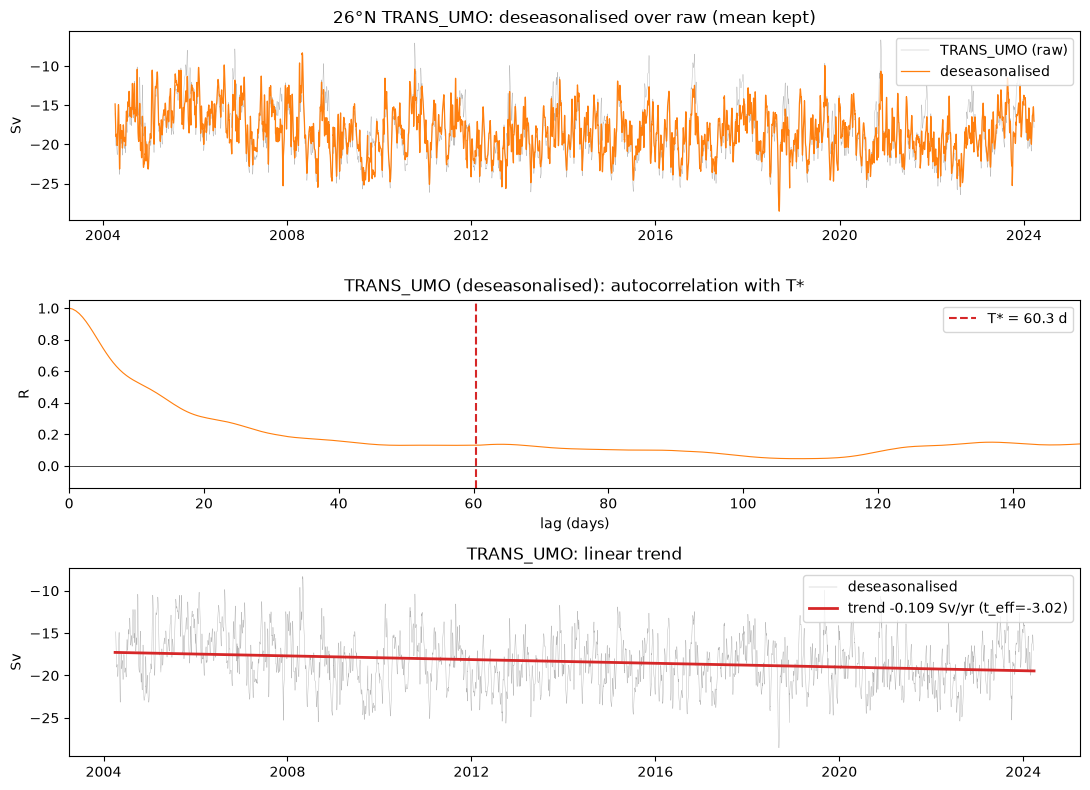

In [7]:
# UMO: deseasonalised-over-raw, autocorrelation with T*, and trend fit
figU, axs = plt.subplots(3, 1, figsize=(11, 8))

axs[0].plot(umo["TIME"], umo, lw=0.3, color="0.7", label="TRANS_UMO (raw)")
axs[0].plot(umo["TIME"], umo_des, lw=0.9, color="C1", label="deseasonalised")
axs[0].set_ylabel("Sv"); axs[0].set_title("26°N TRANS_UMO: deseasonalised over raw (mean kept)")
axs[0].legend(loc="upper right")

v = umo_des.values[np.isfinite(umo_des.values)]
Ru = autocorr(v, biased=True); lags = np.arange(Ru.size) * dt_days
axs[1].plot(lags, Ru, lw=0.8, color="C1"); axs[1].axhline(0, color="k", lw=0.5)
axs[1].axvline(tstar_umo, color="C3", ls="--", label=f"T* = {tstar_umo:.1f} d")
axs[1].set_xlim(0, 150); axs[1].set_xlabel("lag (days)"); axs[1].set_ylabel("R")
axs[1].set_title("TRANS_UMO (deseasonalised): autocorrelation with T*"); axs[1].legend()

t_years = (umo["TIME"].values - umo["TIME"].values[0]) / np.timedelta64(365, "D")
axs[2].plot(umo["TIME"], umo_des, lw=0.3, color="0.7", label="deseasonalised")
axs[2].plot(umo["TIME"], res_umo.slope * t_years + res_umo.intercept, color="C3", lw=2,
            label=f"trend {res_umo.slope:.3f} Sv/yr (t_eff={res_umo.t_eff:.2f})")
axs[2].set_ylabel("Sv"); axs[2].set_title("TRANS_UMO: linear trend"); axs[2].legend(loc="upper right")

figU.tight_layout()
figU.savefig(FIG_DIR / "fig2A_umo_all.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
import xarray as xr

In [10]:
from correlation_trends.correlation import cross_correlation

ek  = transports["TRANS_EKMAN"]
moc = transports["MOC"]

# --- Check 1: common grid + matched processing ---
# Both are from the same RAPID 12-hourly product on the same TIME axis, so no
# pre-filtering is needed. Align on TIME and drop rows where either is NaN.
both = xr.Dataset({"ek": ek, "moc": moc}).dropna("TIME")
ek_v, moc_v = both["ek"].values, both["moc"].values
print(f"paired N = {ek_v.size}, span {str(both['TIME'].values[0])[:10]} to {str(both['TIME'].values[-1])[:10]}")

# --- Check 2: cross-correlate RAW and DESEASONALISED ---
ek_des  = remove_seasonal_cycle(both["ek"]).values
moc_des2 = remove_seasonal_cycle(both["moc"]).values

lags_raw, r_raw = cross_correlation(ek_v, moc_v)
lags_des, r_des = cross_correlation(ek_des, moc_des2)
lag_days_raw = lags_raw * dt_days
lag_days_des = lags_des * dt_days

# --- Check 3: peak lag (search within +/- 120 days, where physics lives) ---
win = np.abs(lag_days_des) <= 120
k_des = np.argmax(r_des[win])
peak_lag_des = lag_days_des[win][k_des]
peak_r_des   = r_des[win][k_des]
# same for raw
k_raw = np.argmax(r_raw[np.abs(lag_days_raw) <= 120])
peak_lag_raw = lag_days_raw[np.abs(lag_days_raw) <= 120][k_raw]
peak_r_raw   = r_raw[np.abs(lag_days_raw) <= 120][k_raw]

print(f"RAW  peak: r={peak_r_raw:.3f} at lag {peak_lag_raw:+.1f} d")
print(f"DES  peak: r={peak_r_des:.3f} at lag {peak_lag_des:+.1f} d")
lead = "EKMAN leads MOC" if peak_lag_des > 0 else ("MOC leads EKMAN" if peak_lag_des < 0 else "no lead/lag")
print(f"sign convention: positive lag = y (MOC) leads x (EKMAN); negative = EKMAN leads MOC")
print(f"=> {lead} by {abs(peak_lag_des):.1f} days")

paired N = 14579, span 2004-04-07 to 2024-03-22
RAW  peak: r=0.712 at lag -0.5 d
DES  peak: r=0.718 at lag -0.5 d
sign convention: positive lag = y (MOC) leads x (EKMAN); negative = EKMAN leads MOC
=> MOC leads EKMAN by 0.5 days


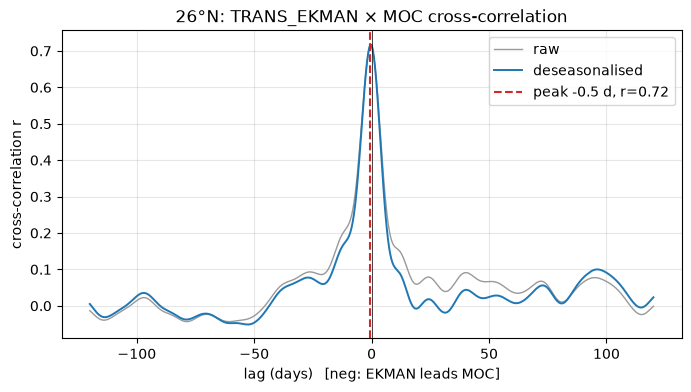

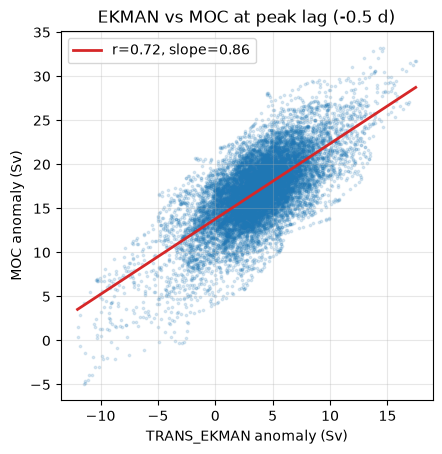

In [11]:
# --- Figure: cross-correlation vs lag, raw and deseasonalised ---
figX, ax = plt.subplots(figsize=(8, 4))
sel = np.abs(lag_days_des) <= 120
ax.plot(lag_days_raw[np.abs(lag_days_raw) <= 120], r_raw[np.abs(lag_days_raw) <= 120],
        lw=1.0, color="0.6", label="raw")
ax.plot(lag_days_des[sel], r_des[sel], lw=1.4, color="C0", label="deseasonalised")
ax.axvline(0, color="k", lw=0.5)
ax.axvline(peak_lag_des, color="C3", ls="--", label=f"peak {peak_lag_des:+.1f} d, r={peak_r_des:.2f}")
ax.set_xlabel("lag (days)   [neg: EKMAN leads MOC]"); ax.set_ylabel("cross-correlation r")
ax.set_title("26°N: TRANS_EKMAN × MOC cross-correlation")
ax.legend(); ax.grid(alpha=0.3)
figX.savefig(FIG_DIR / "fig2B_crosscorr.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Figure: scatter at peak lag (deseasonalised) ---
# peak lag ~0, so align directly; shift if peak_lag != 0
shift = int(round(peak_lag_des / dt_days))
if shift == 0:
    xx, yy = ek_des, moc_des2
else:
    xx = ek_des[:-abs(shift)] if shift > 0 else ek_des[abs(shift):]
    yy = moc_des2[abs(shift):] if shift > 0 else moc_des2[:-abs(shift)]
figSc, ax = plt.subplots(figsize=(4.8, 4.8))
ax.scatter(xx, yy, s=3, alpha=0.15)
b, a = np.polyfit(xx, yy, 1)
xs = np.array([xx.min(), xx.max()])
ax.plot(xs, b*xs + a, color="C3", lw=2, label=f"r={peak_r_des:.2f}, slope={b:.2f}")
ax.set_xlabel("TRANS_EKMAN anomaly (Sv)"); ax.set_ylabel("MOC anomaly (Sv)")
ax.set_title(f"EKMAN vs MOC at peak lag ({peak_lag_des:+.1f} d)")
ax.legend(); ax.grid(alpha=0.3)
figSc.savefig(FIG_DIR / "fig2B_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
# effective sample size from the two series' persistence (use the more persistent bound)
tstar_ek  = integral_timescale(ek_des,  dt_days, biased=True)
tstar_moc = integral_timescale(moc_des2, dt_days, biased=True)
n_eff_pair = (ek_v.size * dt_days) / (2 * max(tstar_ek, tstar_moc))
# significance of a correlation: t = r*sqrt((n_eff-2)/(1-r^2))
from scipy import stats
r = peak_r_des
t_stat = r * np.sqrt((n_eff_pair - 2) / (1 - r**2))
p_val = 2 * stats.t.sf(abs(t_stat), n_eff_pair - 2)
print(f"T*_EK={tstar_ek:.1f} d, T*_MOC={tstar_moc:.1f} d")
print(f"N={ek_v.size}, N_eff≈{n_eff_pair:.0f}, r={r:.3f} (r²={r**2:.2f})")
print(f"t={t_stat:.1f}, p={p_val:.1e} -> {'SIGNIFICANT' if p_val<0.05 else 'not significant'} at 95%")

T*_EK=6.9 d, T*_MOC=18.7 d
N=14579, N_eff≈195, r=0.718 (r²=0.52)
t=14.3, p=3.5e-32 -> SIGNIFICANT at 95%


In [13]:
from correlation_trends.data_io import load_ts_gridded
from correlation_trends.geostrophy import interior_geostrophic_transport

ts = load_ts_gridded()                 
print(ts)                              # confirm TEMP_WEST/EAST, PSAL_WEST/EAST on PRESSURE x TIME
geo = interior_geostrophic_transport(ts, z_max=1100.0)   # upper mid-ocean, integrated to 1100 m
print("geostrophic transport:", geo.sizes["TIME"], "points,",
      f"mean {float(geo.mean()):.2f} Sv, span {str(geo['TIME'].values[0])[:10]}–{str(geo['TIME'].values[-1])[:10]}")

Loading 1 RAPID 26°N dataset(s):
  0. ts_gridded.nc: RAPID gridded temperature and salinity



python(71816) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


<xarray.Dataset> Size: 509MB
Dimensions:            (depth: 242, TIME: 14599)
Coordinates:
    PRESSURE           (depth) float64 2kB ...
  * TIME               (TIME) datetime64[ns] 117kB 2004-04-02 ... 2024-03-27
Dimensions without coordinates: depth
Data variables: (12/18)
    TEMP_WEST          (depth, TIME) float64 28MB ...
    PSAL_WEST          (depth, TIME) float64 28MB ...
    TEMP_WB3           (depth, TIME) float64 28MB ...
    PSAL_WB3           (depth, TIME) float64 28MB ...
    TEMP_EAST          (depth, TIME) float64 28MB ...
    PSAL_EAST          (depth, TIME) float64 28MB ...
    ...                 ...
    TEMP_EAST_FLAG     (depth, TIME) float64 28MB ...
    PSAL_EAST_FLAG     (depth, TIME) float64 28MB ...
    TEMP_MARWEST_FLAG  (depth, TIME) float64 28MB ...
    PSAL_MARWEST_FLAG  (depth, TIME) float64 28MB ...
    TEMP_MAREAST_FLAG  (depth, TIME) float64 28MB ...
    PSAL_MAREAST_FLAG  (depth, TIME) float64 28MB ...
Attributes: (12/38)
    title:                 

paired N=14579 | geo mean -13.46 Sv (std 5.50) | UMO mean -18.37 Sv (std 3.42) | r=0.763


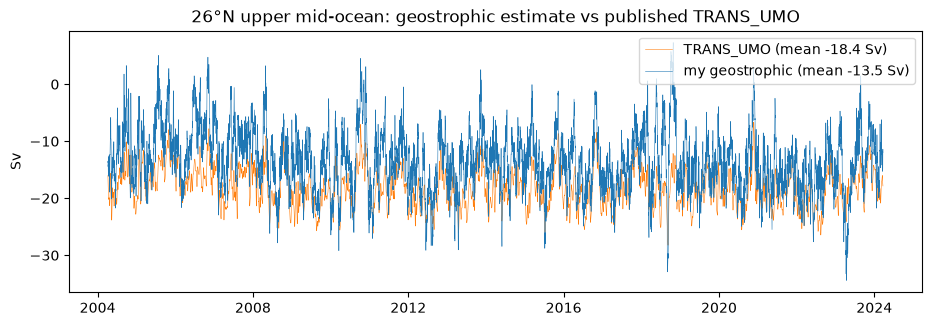

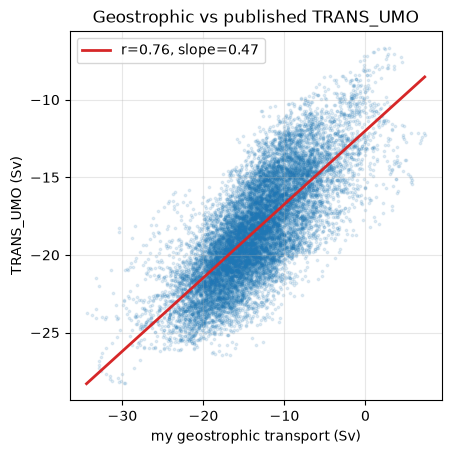

In [14]:
umo = transports["TRANS_UMO"]

# common grid (identical TIME here) + drop rows where either is NaN
pair = xr.Dataset({"geo": geo, "umo": umo}).dropna("TIME")
g, u = pair["geo"].values, pair["umo"].values
r_geo = np.corrcoef(g, u)[0, 1]
print(f"paired N={g.size} | geo mean {g.mean():.2f} Sv (std {g.std():.2f}) | "
      f"UMO mean {u.mean():.2f} Sv (std {u.std():.2f}) | r={r_geo:.3f}")

FIG_DIR = root / "figures"; FIG_DIR.mkdir(exist_ok=True)

# --- Figure: overlay on a common time axis ---
fig1, ax = plt.subplots(figsize=(11, 3.4))
ax.plot(pair["TIME"], u, lw=0.4, color="C1", label=f"TRANS_UMO (mean {u.mean():.1f} Sv)")
ax.plot(pair["TIME"], g, lw=0.4, color="C0", label=f"my geostrophic (mean {g.mean():.1f} Sv)")
ax.set_ylabel("Sv"); ax.set_title("26°N upper mid-ocean: geostrophic estimate vs published TRANS_UMO")
ax.legend(loc="upper right"); fig1.savefig(FIG_DIR / "fig1_geo_overlay.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Figure: scatter + regression ---
b, a = np.polyfit(g, u, 1)
fig2, ax = plt.subplots(figsize=(4.8, 4.8))
ax.scatter(g, u, s=3, alpha=0.12)
xs = np.array([g.min(), g.max()]); ax.plot(xs, b*xs + a, color="C3", lw=2,
        label=f"r={r_geo:.2f}, slope={b:.2f}")
ax.set_xlabel("my geostrophic transport (Sv)"); ax.set_ylabel("TRANS_UMO (Sv)")
ax.set_title("Geostrophic vs published TRANS_UMO"); ax.legend(); ax.grid(alpha=0.3)
fig2.savefig(FIG_DIR / "fig1_geo_scatter.png", dpi=150, bbox_inches="tight")
plt.show()